# Expansion Analysis

This notebook summarizes the latest materialized synthetic expansion analysis, shows synthetic-only power-flow stress based on compact summary tables, and maps expansion cost envelopes per supplied synthetic grid area.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_postprocessing_dir() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "plotting").is_dir() and (candidate / "expansion").is_dir():
            return candidate
    raise FileNotFoundError("Could not find GridExpand/5.postprocessing from the notebook working directory.")


POSTPROCESSING_DIR = find_postprocessing_dir()
if str(POSTPROCESSING_DIR) not in sys.path:
    sys.path.insert(0, str(POSTPROCESSING_DIR))

from expansion import grid_expansion
from plotting import geoplotting, powerflow_plotting

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


In [2]:
# Set ANALYSIS_KEY to None to use the latest materialized expansion analysis.
ANALYSIS_KEY = None

# Set SYNTHETIC_SUMMARY_RUN_NAME to None to use the latest synthetic compact summary run.
# The cutoff overview uses compact summary tables. For expansion-oriented
# diagnostics this should normally be the post-electrification stage.
SYNTHETIC_SUMMARY_RUN_NAME = None
SUMMARY_STAGE = "post"
PLZ = None
SCENARIO_ID = None

ASSET_CUTOFF_PERCENTILE = 1.0
OUTPUT_DIR = POSTPROCESSING_DIR / "plotting" / "output" / "expansion"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Load Expansion Analysis

The materialized expansion analysis is loaded once here and reused by the following plots. Summary tables are collected at the bottom of the notebook so the visual analysis comes first.


In [3]:
expansion_tables = grid_expansion.load_expansion_overview(analysis_key=ANALYSIS_KEY)
analysis_key = expansion_tables["analysis_key"]
analysis_key


'coldest_week_electricity_heat_full_post'

## Synthetic Power-Flow Stress Overview

This reuses the retained-asset cutoff plot from the power-flow comparison workflow, but shows the synthetic run only. The plot is based on compact summary rows, so it stays lightweight even for many grids.


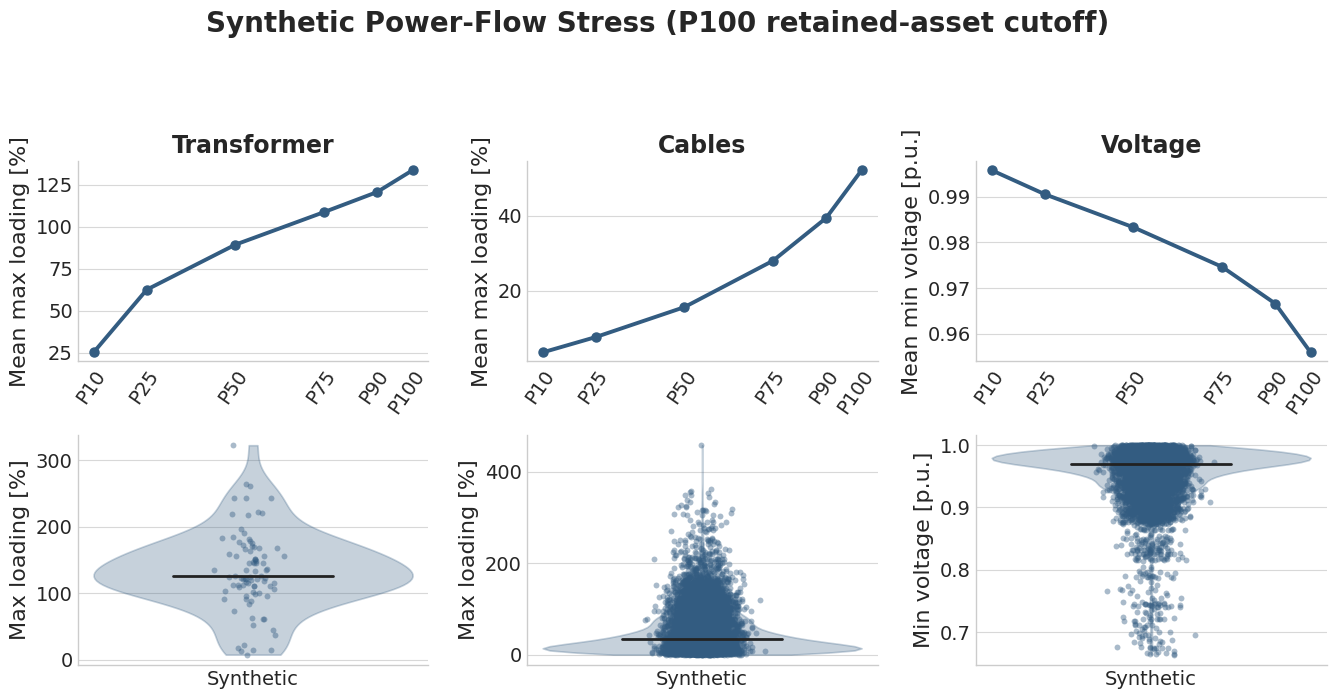

In [4]:
synthetic_summary = pd.DataFrame()
try:
    synthetic_profile = powerflow_plotting.load_synthetic_powerflow_cutoff_profile(
        run_name=SYNTHETIC_SUMMARY_RUN_NAME,
        stage=SUMMARY_STAGE,
        scenario_id=SCENARIO_ID,
        plz=PLZ,
    )
    synthetic_summary = (
        synthetic_profile.groupby(["metric", "asset_type"], as_index=False)
        .agg(assets=("asset_id", "count"), grids=("grid", "nunique"))
        .sort_values(["metric", "asset_type"])
    )
    fig = powerflow_plotting.plot_powerflow_asset_cutoff_overview_static(
        synthetic_profile,
        group_col="comparison_group",
        asset_cutoff_percentile=ASSET_CUTOFF_PERCENTILE,
        asset_percentiles=(0.10, 0.25, 0.50, 0.75, 0.90, 1.0),
        worst_asset_per_grid=False,
        title="Synthetic Power-Flow Stress",
        save_path=OUTPUT_DIR / "synthetic_asset_cutoff_overview",
    )
    plt.show()
except ValueError as exc:
    print(exc)


## Weekly Power-Flow Diagnostics

These plots reuse the raw full power-flow run behind the materialized expansion analysis. The voltage histogram summarizes grid-level voltage extrema over the analyzed week; the transformer import plot shows the weekly import pattern and load-duration curve across the synthetic grid population.


In [5]:
analysis_meta = expansion_tables["analysis_run"].iloc[0]
raw_run_name = analysis_meta["run_name"]
raw_stage = analysis_meta["stage"]
raw_scenario_id = None if pd.isna(analysis_meta["scenario_id"]) else int(analysis_meta["scenario_id"])
raw_ags = None if pd.isna(analysis_meta["ags"]) else int(analysis_meta["ags"])
raw_plz = None if pd.isna(analysis_meta["plz"]) else int(analysis_meta["plz"])

voltage_summary = powerflow_plotting.voltage_deviation_summary_db(
    run_name=raw_run_name,
    stages=(raw_stage,),
    scenario_id=raw_scenario_id,
    ags=raw_ags,
    plz=raw_plz,
)
voltage_fig = powerflow_plotting.plot_voltage_deviation_histogram(
    voltage_summary,
    lower_limit=0.95,
    upper_limit=1.03,
    show=False,
)
try:
    powerflow_plotting.save_plotly_figure(
        voltage_fig,
        OUTPUT_DIR / f"{analysis_key}_voltage_deviation_histogram",
        formats=("svg", "png"),
        width=820,
        height=420,
    )
except RuntimeError as exc:
    print(f"Could not export voltage histogram: {exc}")
display(voltage_fig)


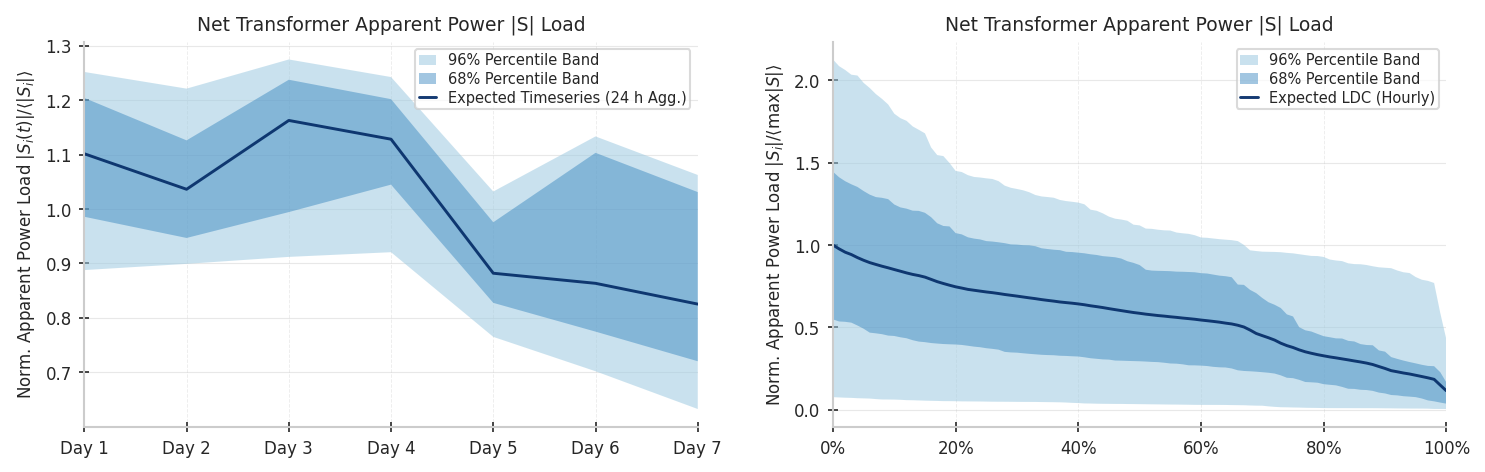

In [6]:
transformer_distribution = powerflow_plotting.transformer_import_distribution_db(
    run_name=raw_run_name,
    stage=raw_stage,
    scenario_id=raw_scenario_id,
    ags=raw_ags,
    plz=raw_plz,
)
transformer_fig = powerflow_plotting.plot_transformer_import_distributions_matplotlib(
    transformer_distribution,
    metrics=("s",),
    show=False,
)
transformer_fig.savefig(
    OUTPUT_DIR / f"{analysis_key}_transformer_import_distributions.svg",
    bbox_inches="tight",
)
transformer_fig.savefig(
    OUTPUT_DIR / f"{analysis_key}_transformer_import_distributions.png",
    dpi=240,
    bbox_inches="tight",
)
plt.show()


## Expansion Cost Envelopes

The envelope maps aggregate building/bus points to the supplied synthetic grid areas and color each envelope by the materialized expansion cost. Values are clipped at the selected quantile so one very expensive grid does not dominate the color scale.


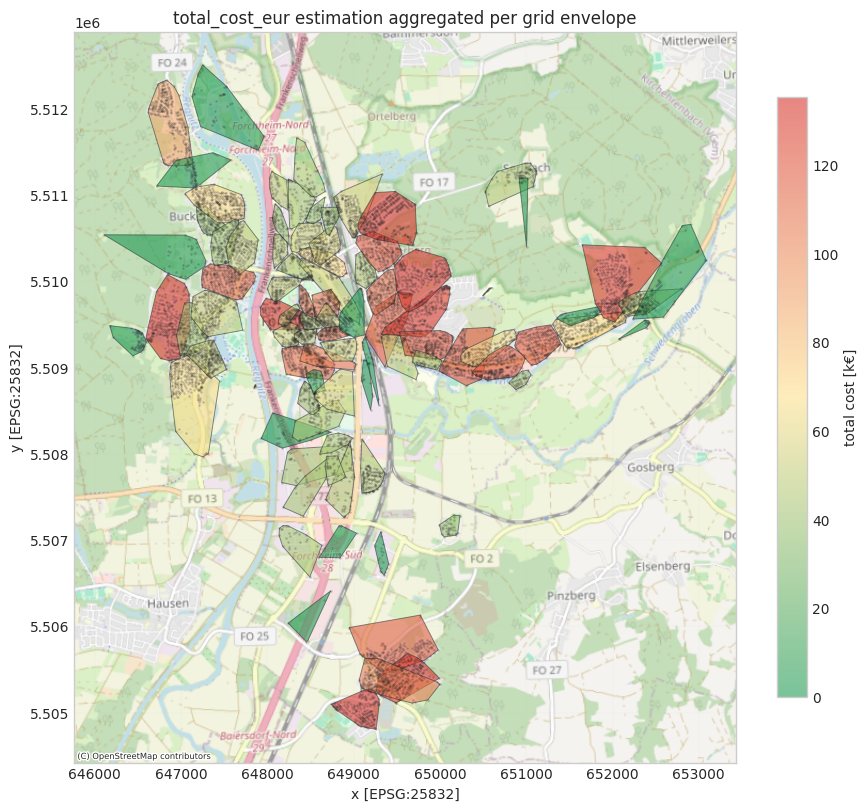

In [7]:
fig, ax, total_envelope_data = geoplotting.plot_synthetic_expansion_envelopes(
    analysis_key=analysis_key,
    value_column="total_cost_eur", #transformer_cost_eur, cable_cost_eur, total_cost_eur
    clip_quantile=0.95,
    log_scale=False,
    cmap="cost_green_red",
    output_path=OUTPUT_DIR / f"{analysis_key}_total_cost_envelopes.svg",
)
plt.show()


## Summary Tables

Compact table outputs for the materialized expansion analysis and the plotted diagnostics.


In [8]:
expansion_tables["analysis_run"]


,expansion_analysis_run_id,analysis_key,assumption_key,run_name,stage,scenario_id,ags,plz,created_at,note
0,4,coldest_week_electricity_heat_full_post,de_lv_heuristic_2026,baseline_static_min_temperature_week_full_powe...,post,None,9474126,91301,2026-07-05 15:32:05.837700+00:00,Full synthetic coldest-week electricity+heat e...


In [9]:
expansion_tables["cost_summary"]


,grids_with_line_rows,cable_segments,cable_segments_requiring_expansion,cable_segments_overloaded,cable_cost_eur,transformers,transformers_requiring_expansion,transformers_overloaded,transformer_cost_eur,total_cost_eur
0,89,12153,286,286,909566.575019,89,71,68,4372000.0,5.281567e+06


In [10]:
expansion_tables["grid_cost_summary"].head(10)


,grid_case_id,plz,kcid,bcid,cable_segments,cable_segments_requiring_expansion,cable_cost_eur,max_cable_loading_percent,transformer_rated_power_kva,required_transformer_kva,additional_transformer_kva,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,total_cost_eur
0,1894,91301,10,5,284,9,121162.977911,457.826779,630.0,2050.0,1420.0,True,100000.0,322.795302,221162.977911
1,1626,91301,1,2,240,11,53985.948330,361.069989,630.0,1450.0,820.0,True,100000.0,222.571809,153985.948330
2,1622,91301,1,5,325,15,45839.353317,284.107171,630.0,1700.0,1070.0,True,100000.0,263.915659,145839.353317
3,1838,91301,7,12,373,9,39331.425876,252.160740,630.0,1650.0,1020.0,True,100000.0,261.729136,139331.425876
4,1698,91301,4,1,134,7,35592.844848,161.568255,630.0,1200.0,570.0,True,100000.0,184.924093,135592.844848
5,1858,91301,9,5,370,10,34724.218314,159.645571,630.0,1100.0,470.0,True,100000.0,172.559095,134724.218314
6,1686,91301,3,3,374,11,31800.066686,248.169890,630.0,1400.0,770.0,True,100000.0,219.077089,131800.066686
7,1890,91301,10,4,222,7,31747.886817,208.807470,630.0,1550.0,920.0,True,100000.0,244.078309,131747.886817
8,1898,91301,10,6,260,7,22878.994860,175.543157,630.0,1250.0,620.0,True,100000.0,197.455481,122878.994860
9,1930,91301,11,6,237,7,21389.362805,172.527483,630.0,1400.0,770.0,True,100000.0,217.511804,121389.362805


In [11]:
expansion_tables["cable_summary_by_type"]


,visible_std_type,cable_segments,cable_segments_requiring_expansion,length_km,estimated_cost_eur,max_loading_percent
0,NAYY_4_120,1082,191,141.991532,403980.196760,361.069989
1,NAYY_4_240,42,21,11.685431,191559.788089,457.826779
2,NAYY_4_185,51,34,10.820713,156443.617623,333.672324
3,NAYY_4_300,36,19,9.796569,122586.896939,338.553342
4,NAYY_4_150,35,21,5.648733,34996.075610,333.787095
5,NAYY_4_50,10429,0,226.009026,0.000000,79.594196
6,NYY_4_35,139,0,4.554462,0.000000,69.195764
7,NYY_4_70,339,0,14.355013,0.000000,40.837957


In [12]:
expansion_tables["transformer_summary_by_basis"]


,transformer_cost_basis,transformers,transformers_requiring_expansion,additional_transformer_kva,estimated_cost_eur,max_loading_percent
0,station_rebuild_boundary_case_gt_1000kva,23,23,15210.0,2300000.0,322.795302
1,all_in_replacement_to_800kva,22,22,2900.0,924000.0,169.960525
2,all_in_replacement_to_1000kva,16,16,5680.0,768000.0,243.521213
3,all_in_replacement_to_630kva,10,10,1000.0,380000.0,146.240318
4,none_existing_capacity_sufficient,18,0,0.0,0.0,95.881512


### Power-Flow Stress Input Coverage


In [13]:
synthetic_summary


,metric,asset_type,assets,grids
0,Cables,cable,44575,89
1,Transformer,transformer,445,89
2,Voltage,bus,44575,89


### Voltage Summary Sample


In [14]:
voltage_summary[["grid", "stage", "n_timesteps", "n_buses", "min_vm_pu", "max_vm_pu"]].head()


,grid,stage,n_timesteps,n_buses,min_vm_pu,max_vm_pu
0,09474126-91301_1_1,post,168,12,0.972379,1.0
1,09474126-91301_2_2,post,168,71,0.964668,1.0
2,09474126-91301_2_4,post,168,250,0.968819,1.0
3,09474126-91301_1_4,post,168,268,0.880840,1.0
4,09474126-91301_2_6,post,168,287,0.941593,1.0


### Envelope Cost Ranking Sample


In [15]:
total_envelope_data["grid_metrics"].head(5)


,grid_case_id,kcid,bcid,cable_segments,cable_segments_requiring_expansion,cable_cost_eur,max_cable_loading_percent,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,additional_transformer_kva,total_cost_eur
0,1894,10,5,284,9,121162.977911,457.826779,True,100000.0,322.795302,1420.0,221162.977911
1,1626,1,2,240,11,53985.948330,361.069989,True,100000.0,222.571809,820.0,153985.948330
2,1622,1,5,325,15,45839.353317,284.107171,True,100000.0,263.915659,1070.0,145839.353317
3,1838,7,12,373,9,39331.425876,252.160740,True,100000.0,261.729136,1020.0,139331.425876
4,1698,4,1,134,7,35592.844848,161.568255,True,100000.0,184.924093,570.0,135592.844848
